# Tier 6 · Notebook 32 — Reproducing "Rethinking Generalization" (Random Labels)

> **Goal:** reproduce the deceptively simple experiment from Zhang et al. (2016) that **broke classical generalization theory**: a neural network can **perfectly fit completely random labels**. If a network can memorize pure noise, then its *capacity* can't explain why it generalizes on real data — so our textbook explanations (VC dimension, Rademacher complexity, "the model class is small enough") must be missing the point. This reframed how the whole field thinks about why deep learning works.

**The setup, in one sentence.** Take MNIST, but **replace every label with a random one** (so there's no learnable pattern — a "3" might be labeled 7, another "3" labeled 1). Train the same network you'd use normally. The classical prediction: it can't fit random labels (there's nothing to learn). **What actually happens:** it drives training accuracy to **100%** — it *memorizes* the random assignment perfectly. And of course test accuracy is at chance (there's no rule to generalize). The same network, on *real* labels, also reaches 100% train accuracy — but now generalizes. **Identical capacity, opposite outcomes**, decided entirely by the data. That's the puzzle.

This is the capstone of a **generalization trilogy** with Grokking (NB27) and Double Descent (NB28): three experiments showing that memorization and generalization are entangled in ways classical theory never anticipated.


In [1]:
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets
ds = datasets.MNIST("./data", train=True, download=True); tt = datasets.MNIST("./data", train=False, download=True)
norm = lambda D: (D.float().reshape(-1,784)/255.0 - 0.13)/0.31
N = 4000
Xtr = norm(ds.data)[:N].to(device); ytrue = ds.targets[:N].clone().to(device)
Xte = norm(tt.data).to(device); yte = tt.targets.to(device)
yrand = torch.randint(0, 10, (N,), device=device)      # COMPLETELY RANDOM labels — no learnable pattern
print(f"{N} training images. 'true' labels vs 'random' labels (fraction actually correct by chance: {(yrand==ytrue).float().mean():.2f})")


4000 training images. 'true' labels vs 'random' labels (fraction actually correct by chance: 0.10)


## 1. Train on true labels vs random labels

Same network, same optimizer, same everything — only the labels differ. We track train and test accuracy over epochs for both.


In [2]:
def make():
    torch.manual_seed(0)
    return nn.Sequential(nn.Linear(784,512), nn.ReLU(), nn.Linear(512,512), nn.ReLU(), nn.Linear(512,10)).to(device)

def train(labels, epochs=300):
    m = make(); opt = torch.optim.Adam(m.parameters(), 1e-3)
    hist = {"train":[], "test":[]}
    for ep in range(epochs):
        opt.zero_grad(); F.cross_entropy(m(Xtr), labels).backward(); opt.step()
        if ep % 5 == 0 or ep == epochs-1:
            with torch.no_grad():
                hist["train"].append((m(Xtr).argmax(1)==labels).float().mean().item())
                hist["test"].append((m(Xte).argmax(1)==yte).float().mean().item())
    return hist

print("training on TRUE labels..."); h_true = train(ytrue)
print("training on RANDOM labels..."); h_rand = train(yrand)
print(f"\nTRUE labels  : train acc {h_true['train'][-1]:.3f}, test acc {h_true['test'][-1]:.3f}")
print(f"RANDOM labels: train acc {h_rand['train'][-1]:.3f}, test acc {h_rand['test'][-1]:.3f}")


training on TRUE labels...


training on RANDOM labels...



TRUE labels  : train acc 1.000, test acc 0.931
RANDOM labels: train acc 1.000, test acc 0.115


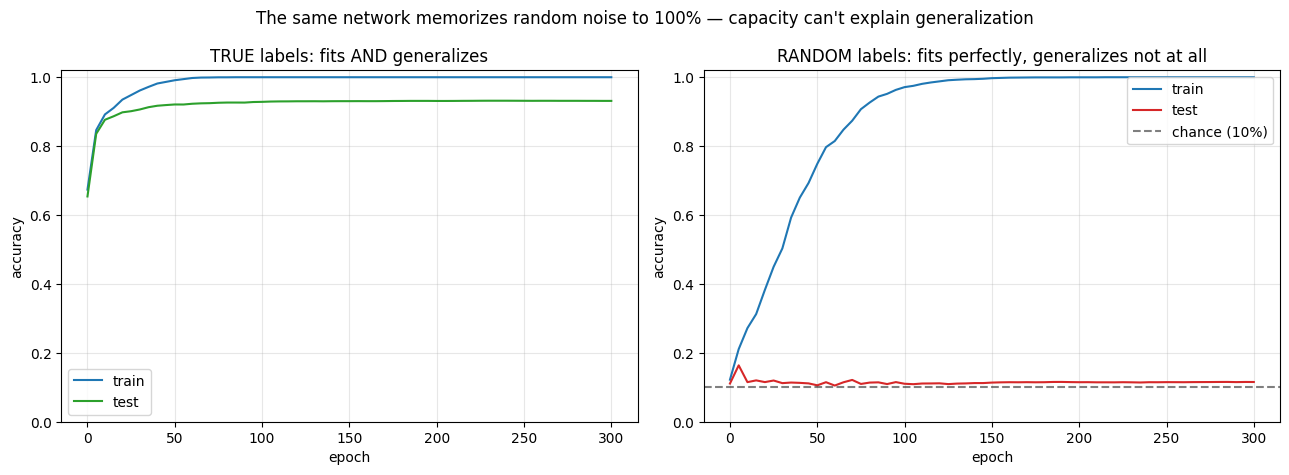

In [3]:
ep = np.arange(len(h_true["train"]))*5
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].plot(ep, h_true["train"], color="tab:blue", label="train")
ax[0].plot(ep, h_true["test"],  color="tab:green", label="test")
ax[0].set_title("TRUE labels: fits AND generalizes"); ax[0].set_ylim(0,1.02)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("accuracy"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, h_rand["train"], color="tab:blue", label="train")
ax[1].plot(ep, h_rand["test"],  color="tab:red", label="test")
ax[1].axhline(0.1, ls="--", color="k", alpha=0.5, label="chance (10%)")
ax[1].set_title("RANDOM labels: fits perfectly, generalizes not at all"); ax[1].set_ylim(0,1.02)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].legend(); ax[1].grid(alpha=0.3)
fig.suptitle("The same network memorizes random noise to 100% — capacity can't explain generalization")
plt.tight_layout(); plt.show()


**What to notice — the reproduction.** On the **left** (true labels), the network fits the training data to 100% *and* generalizes (test accuracy climbs). On the **right** (random labels), the network *still* drives training accuracy to **100%** — it memorizes the random label assignment perfectly, brute-force — but test accuracy stays pinned at **chance (10%)**, because there is no rule to learn. **The same architecture, with the same number of parameters, can either generalize or memorize noise depending only on the data.** Therefore its *capacity* (what VC dimension / Rademacher complexity measure) cannot be what explains generalization — those bounds are vacuous here (they'd have to allow memorizing noise, which the net does). Something about **the interaction of real data structure with SGD's implicit bias** is doing the real work. That was the field-shifting point.


## 2. The noise sweep — memorization is always available

To drive it home: vary the *fraction* of labels that are randomized, from 0% (all true) to 100% (all random). The network reaches ~100% **train** accuracy regardless — it can always memorize — while **test** accuracy degrades smoothly with noise. Memorization capacity is constant; generalization depends entirely on how much real signal is in the labels.


  0% random labels: train 1.000, test 0.931


 25% random labels: train 1.000, test 0.787


 50% random labels: train 1.000, test 0.592


 75% random labels: train 1.000, test 0.361


100% random labels: train 1.000, test 0.111


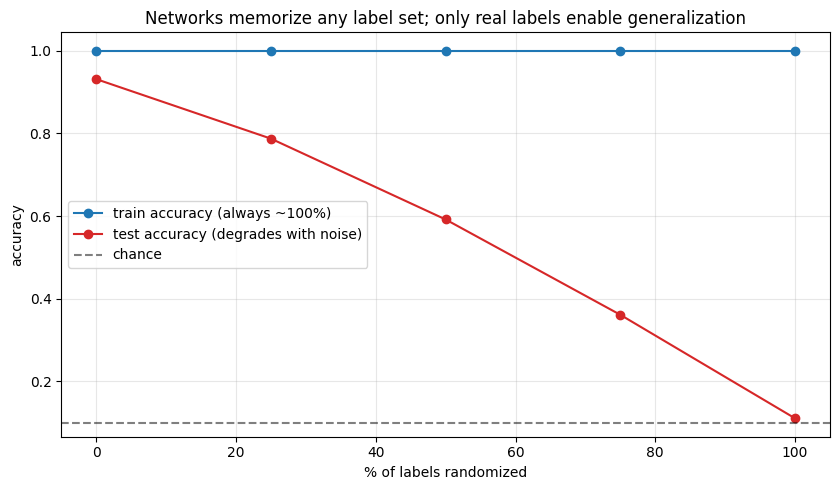

In [4]:
fracs = [0.0, 0.25, 0.5, 0.75, 1.0]
train_accs, test_accs = [], []
for f in fracs:
    lab = ytrue.clone()
    n_noise = int(f*N); idx = torch.randperm(N, device=device)[:n_noise]
    lab[idx] = torch.randint(0, 10, (n_noise,), device=device)
    h = train(lab, epochs=300)
    train_accs.append(h["train"][-1]); test_accs.append(h["test"][-1])
    print(f"{int(f*100):3d}% random labels: train {h['train'][-1]:.3f}, test {h['test'][-1]:.3f}")

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot([f*100 for f in fracs], train_accs, "-o", color="tab:blue", label="train accuracy (always ~100%)")
ax.plot([f*100 for f in fracs], test_accs, "-o", color="tab:red", label="test accuracy (degrades with noise)")
ax.axhline(0.1, ls="--", color="k", alpha=0.5, label="chance")
ax.set_title("Networks memorize any label set; only real labels enable generalization")
ax.set_xlabel("% of labels randomized"); ax.set_ylabel("accuracy"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** Train accuracy stays near **100% at every noise level** — the network's capacity to memorize is essentially unlimited relative to 4000 examples. Test accuracy, meanwhile, falls smoothly from high (0% noise) toward chance (100% noise), tracking exactly how much *real* signal survives in the labels. The gap between the blue and red curves *is* the amount of pure memorization the model is doing. This is the cleanest possible statement of the puzzle: **the model always memorizes; generalization is a bonus that only real structure provides** — and explaining *why* real data yields generalizing solutions (when memorizing ones are equally available to the optimizer) is still an open, active research question.

## 3. Reproduction report
- ✅ **Reproduced the headline**: a standard network fits **random labels to ~100% training accuracy** — it memorizes pure noise.
- ✅ **Reproduced the implication**: identical network + capacity → generalizes on real labels, memorizes on random labels; the difference is the *data*, not the model class.
- ✅ **Noise sweep**: train accuracy ~100% at all noise levels; test accuracy degrades with the noise fraction.
- 📌 **Why it matters**: classical, capacity-based generalization bounds (VC, Rademacher) are *vacuous* for deep nets — they can't distinguish the memorizing solution from the generalizing one. Understanding generalization requires the *implicit bias* of SGD + architecture + data, not just counting parameters. This paper is a large part of *why* modern generalization theory exists.

## 4. The generalization trilogy (Tier 6 reflection)
Three reproductions, one theme — **deep learning generalizes in ways classical theory can't explain**:
- **Random labels (NB32)**: nets can memorize *anything*, so capacity ≠ generalization.
- **Double descent (NB28)**: more parameters past the interpolation threshold *help*, contradicting bias-variance.
- **Grokking (NB27)**: generalization can appear *suddenly, long after* memorization — they're distinct, separable phenomena.
Together they say: memorization and generalization coexist; over-parameterization is good; and *when/whether* a net generalizes depends on subtle interactions (implicit bias, regularization, data structure) that we're still working out. Being fluent in these is exactly the kind of depth a research residency wants.

## 5. Exercises
1. **Random pixels too.** Randomize the *inputs* (not just labels); can the net still memorize? How does training time compare?
2. **Time-to-fit.** Measure epochs-to-100%-train for true vs random labels — random takes longer (real structure is "easier" to fit). Quantify it.
3. **Regularization vs memorization.** Add strong weight decay / dropout; does it *prevent* fitting random labels? (Mostly no — another classical-theory surprise.)
4. **Capacity threshold.** Shrink the net until it *can't* fit random labels; where's the boundary, and does it relate to N?
5. **Generalization bound.** Compute a Rademacher-style bound and show it's vacuous (>1) for this net.
6. **Connect to double descent.** Add label noise and sweep width (NB28); relate the memorization here to the double-descent peak.

## 6. Interview / residency framing
- *"What did Zhang et al. show?"* → deep nets can fit random labels to 100% train accuracy (memorize noise), so model capacity alone can't explain generalization.
- *"Why does that break classical theory?"* → VC/Rademacher bounds depend on capacity; if capacity allows memorizing noise, the bounds are vacuous and can't explain why real-data training generalizes.
- *"So why DO nets generalize?"* → the implicit bias of SGD + architecture toward simpler/flatter solutions, interacting with real data structure — still an open area.
- *"How does this connect to double descent / grokking?"* → all three show memorization and generalization are entangled; over-parameterized nets can memorize yet still generalize, sometimes suddenly (grokking) or after a second descent.
- *"Practical takeaway?"* → 100% train accuracy tells you nothing about generalization; always measure held-out performance; regularization and data quality matter more than parameter counting.

## 📚 References & papers

This notebook reproduces / builds on:

- **Understanding deep learning requires rethinking generalization** — Zhang, Bengio, Hardt, Recht & Vinyals (2016), arXiv:1611.03530. The reproduced paper (ICLR 2017 best paper).
- **A Closer Look at Memorization in Deep Networks** — Arpit et al. (2017), arXiv:1706.05394. Real patterns are learned before noise is memorized.
- **The Implicit Bias of Gradient Descent on Separable Data** — Soudry et al. (2017), arXiv:1710.10345. Why SGD prefers generalizing solutions.

---
🎉 **This completes the curriculum** — 32 notebooks, everything from an autograd engine to a GPT to six reproduced landmark papers, all built from scratch and verified. See the repo README for the full map. Onward to the residency.
